# 01 — Data Exploration: US Equities

## Objective
Validate the historical data pipeline and document basic empirical properties of daily returns for a small illustrative basket of liquid US equities.

## Data source
| Field | Value |
|-------|-------|
| **Provider** | Alpaca Markets (historical bars API) |
| **Adjustment** | Split and dividend adjusted (`Adjustment.ALL`) |
| **Frequency** | Daily (1d bars) |
| **Universe** | 14 hand-picked liquid US equities across tech, financials, healthcare, consumer, and energy |
| **Date range** | Jan 2024 — present |

## Known limitations
- The selected universe is **not** a point-in-time universe and is not intended to support claims about an investable cross-sectional strategy. It is used for package validation and exploratory analysis.
- Survivorship bias is present — all names were selected with hindsight.

## Main outputs
1. Normalized price chart
2. Return distributions and fat-tail analysis
3. Cross-sector correlation heatmap
4. Rolling volatility and volatility clustering evidence
5. Summary performance metrics table

> *Note: AI tools were used for cosmetic and presentation edits to this notebook.*

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

from qre.analytics.metrics import full_summary, summary
from qre.data.historical import HistoricalDataStore

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

%matplotlib inline

## 2. Loading data

14 liquid US equities spanning five sectors: technology, financials, healthcare, consumer staples, and energy.

In [2]:
tickers = [
    "NVDA",   # Nvidia
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOGL",  # Alphabet (Google)
    "AMZN",   # Amazon
    "META",   # Meta (Facebook)
    "JPM",    # JPMorgan Chase
    "GS",     # Goldman Sachs
    "V",      # Visa
    "XOM",    # ExxonMobil
    "JNJ",    # Johnson & Johnson
    "WMT",    # Walmart
    "PG",     # Procter & Gamble
    "UNH",    # UnitedHealth
]

store = HistoricalDataStore()

# Load all tickers into wide DataFrames (no API keys needed)
panel = store.load_panel(tickers, "1d")
closes = panel["close"]

print(f"Shape: {closes.shape[0]} trading days x {closes.shape[1]} tickers")
print(f"Date range: {closes.index.min().date()} to {closes.index.max().date()}")
closes.head()

Shape: 590 trading days x 14 tickers
Date range: 2024-01-02 to 2026-05-08


,NVDA,AAPL,MSFT,GOOGL,AMZN,META,JPM,GS,V,XOM,JNJ,WMT,PG,UNH
timestamp,,,,,,,,,,,,,,
2024-01-02 05:00:00+00:00,48.14,183.56,364.59,137.04,149.93,343.59,163.01,369.59,254.57,94.85,149.66,51.77,139.35,514.26
2024-01-03 05:00:00+00:00,47.54,182.19,364.32,137.78,148.47,341.79,162.30,363.39,253.69,95.64,150.60,51.77,138.51,516.83
2024-01-04 05:00:00+00:00,47.97,179.87,361.71,135.27,144.57,344.42,163.38,364.50,255.30,94.81,150.28,51.27,139.26,520.06
2024-01-05 05:00:00+00:00,49.07,179.15,361.52,134.62,145.24,349.21,164.20,367.82,255.38,95.10,150.75,50.93,138.11,512.40
2024-01-08 05:00:00+00:00,52.22,183.48,368.34,137.70,149.10,355.87,163.96,370.12,258.18,93.51,151.12,51.43,139.30,511.58


## 3. Normalized price chart

Index all prices to a base of 100 on the first trading day to make cumulative performance visually comparable across different price levels.

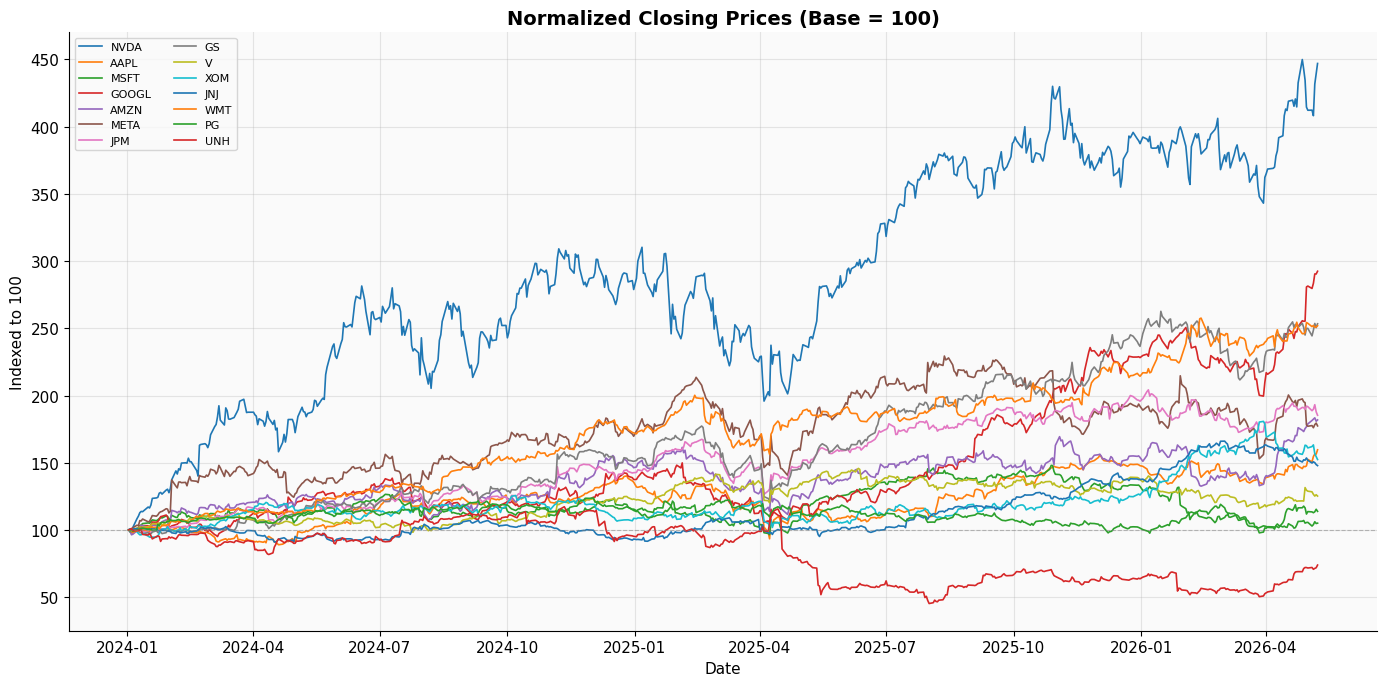

In [3]:
normalized = closes / closes.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1.2, label=col)

ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Normalized Closing Prices (Base = 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed to 100")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()

**Observations:**
- Alpaca Client API uses `Adjustment.ALL` to return adjusted prices accounting for stock splits and dividends on ex-days. NVDA and WMT had 10-for-1 stock splits in mid-2024.
- Raw (unadjusted) prices are important for execution but not for return computation or signal generation.
- Over the selected sample, NVDA had the largest cumulative return among the basket. This should not be interpreted as an ex ante result — the universe is illustrative and was selected with full hindsight.

## 4. Return distributions

Compute simple daily returns and examine their statistical properties. A key question: how well does the normal distribution describe equity returns?

In [4]:
returns = closes.pct_change().dropna()

print(f"Return matrix: {returns.shape[0]} days x {returns.shape[1]} tickers")
returns.describe().round(4)

Return matrix: 589 days x 14 tickers


,NVDA,AAPL,MSFT,GOOGL,AMZN,META,JPM,GS,V,XOM,JNJ,WMT,PG,UNH
count,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000,589.0000
mean,0.0030,0.0009,0.0003,0.0020,0.0012,0.0013,0.0012,0.0017,0.0005,0.0008,0.0007,0.0017,0.0001,-0.0002
std,0.0310,0.0173,0.0151,0.0191,0.0197,0.0239,0.0153,0.0185,0.0132,0.0144,0.0109,0.0140,0.0112,0.0252
min,-0.1697,-0.0925,-0.0999,-0.0750,-0.0898,-0.1133,-0.0749,-0.0921,-0.0774,-0.0720,-0.0759,-0.0653,-0.0501,-0.2238
25%,-0.0136,-0.0069,-0.0068,-0.0084,-0.0094,-0.0107,-0.0057,-0.0073,-0.0052,-0.0074,-0.0048,-0.0057,-0.0059,-0.0091
50%,0.0034,0.0011,0.0008,0.0027,0.0011,0.0010,0.0015,0.0015,0.0012,0.0010,0.0006,0.0015,0.0006,0.0006
75%,0.0199,0.0086,0.0084,0.0116,0.0126,0.0121,0.0093,0.0115,0.0075,0.0100,0.0063,0.0087,0.0065,0.0114
max,0.1872,0.1533,0.1013,0.1022,0.1198,0.2032,0.1154,0.1310,0.0826,0.0500,0.0619,0.0954,0.0414,0.1198


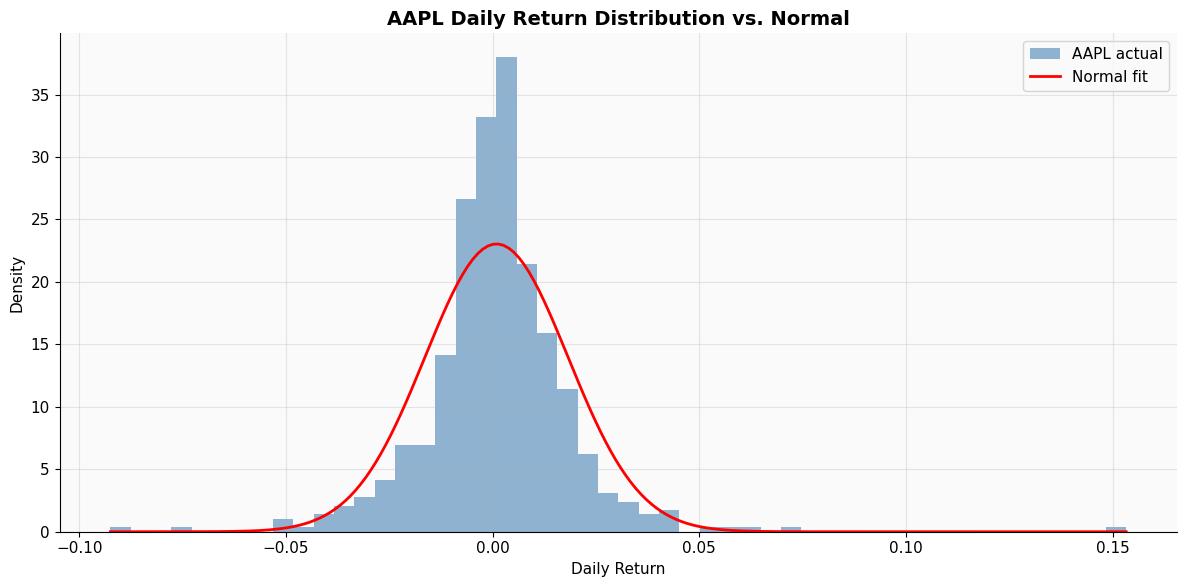

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

aapl_rets = returns["AAPL"]
aapl_rets.hist(
    bins=50, alpha=0.6, label="AAPL actual",
    ax=ax, density=True, color="steelblue",
)

x = np.linspace(float(aapl_rets.min()), float(aapl_rets.max()), 200)
ax.plot(x, norm.pdf(x, float(aapl_rets.mean()), float(aapl_rets.std())),
        "r-", linewidth=2, label="Normal fit")

ax.set_title(
    "AAPL Daily Return Distribution vs. Normal",
    fontsize=14, fontweight="bold",
)
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

In [6]:
print(f"AAPL excess kurtosis: {float(aapl_rets.kurtosis()):.2f}")
print(f"AAPL skewness:       {float(aapl_rets.skew()):.2f}")

AAPL excess kurtosis: 12.56
AAPL skewness:       0.88


**Leptokurtosis** (fat tails + sharp peak) — one of the most well-documented properties of financial returns.

A normal distribution spreads probability relatively evenly across the range. Empirical equity returns concentrate in two places:

1. **At the mean** — most days produce very small moves.
2. **In the tails** — when large moves occur, they are larger than the normal distribution predicts.

The region in between (~1 standard deviation) is **underpopulated** relative to the normal — fewer "medium-sized" moves than expected.

**Implications:**
- **VaR models** that assume normality systematically underestimate tail risk. The 2008 crisis was a "25-sigma event" under Gaussian assumptions — essentially impossible, yet it occurred.
- **Excess kurtosis** measures this departure. The normal distribution has kurtosis = 3 (excess kurtosis = 0). Financial returns typically exhibit excess kurtosis of 5–10+.

Note: pandas `.kurtosis()` returns excess kurtosis (Fisher's definition, subtracting 3), so any value > 0 indicates fatter tails than the normal distribution.

## 5. Correlation analysis

Pairwise Pearson correlations of daily returns. Correlation structure reveals sector factors, common macro exposures, and potential diversification opportunities.

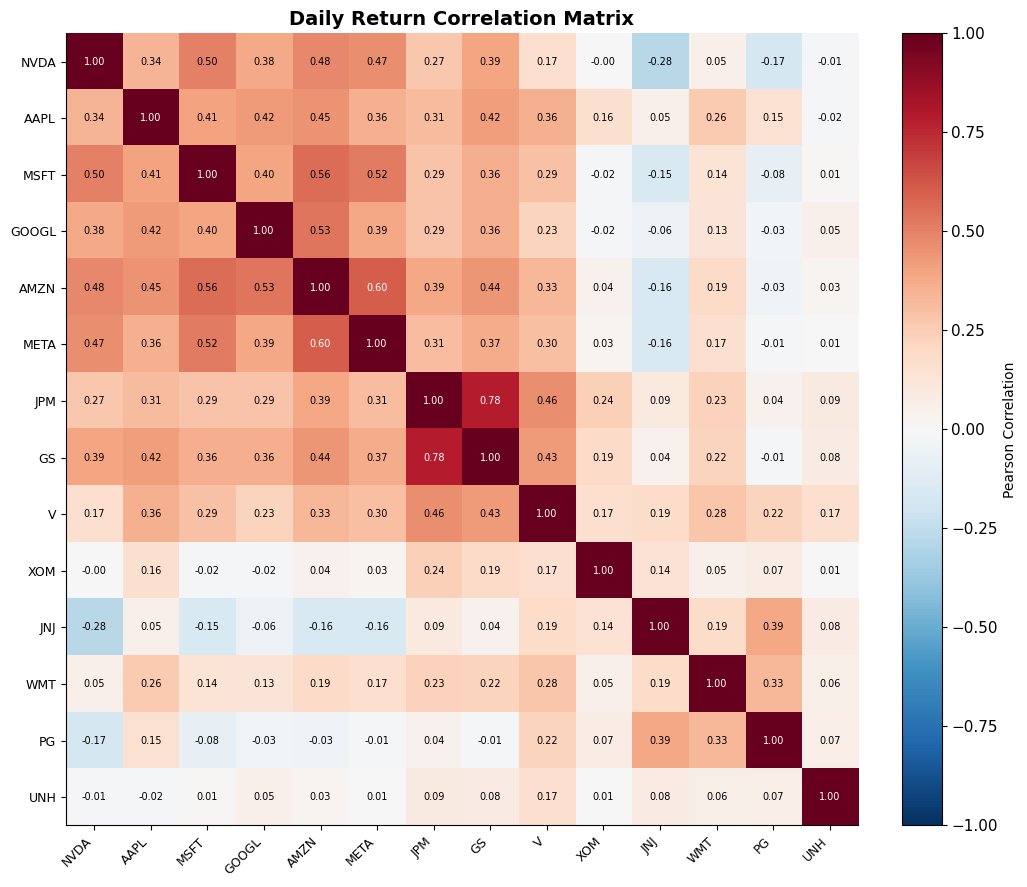

In [7]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(12, 9))
ax.grid(False)
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(tickers, fontsize=9)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        val = float(corr.iloc[i, j])
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Pearson Correlation", fontsize=10)
ax.set_title("Daily Return Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()

**Observations:**
- **Tech cluster** (~0.4 pairwise correlation): NVDA, MSFT, GOOGL, AMZN, META — consistent with a common technology/growth factor.
- **Financials cluster**: GS/JPM correlation of 0.78 (highest in the basket) — both are investment banks with shared exposure to interest rates, deal flow, and credit markets. ~0.4 correlation with V (financial services).
- **Defensive cluster**: PG, WMT, JNJ show slight positive correlation — consumer staples and healthcare tend to co-move during risk-off episodes.
- **Diversifier**: UNH shows minimal correlation with the rest of the basket.
- **Energy**: XOM shows only slight correlation with financials (JPM, GS, V); largely independent of the tech cluster.
- **Market factor**: Most pairwise correlations are positive, reflecting the common market factor. Long-only portfolios cannot diversify away this systematic risk.

**Highest correlations** (all >= 0.5): GS/JPM, META/AMZN, AMZN/MSFT, AMZN/GOOGL, MSFT/NVDA.

## 6. Rolling volatility

21-day rolling annualized volatility for a subset of names. Volatility is not constant — it clusters in regimes, which has direct implications for position sizing and risk management.

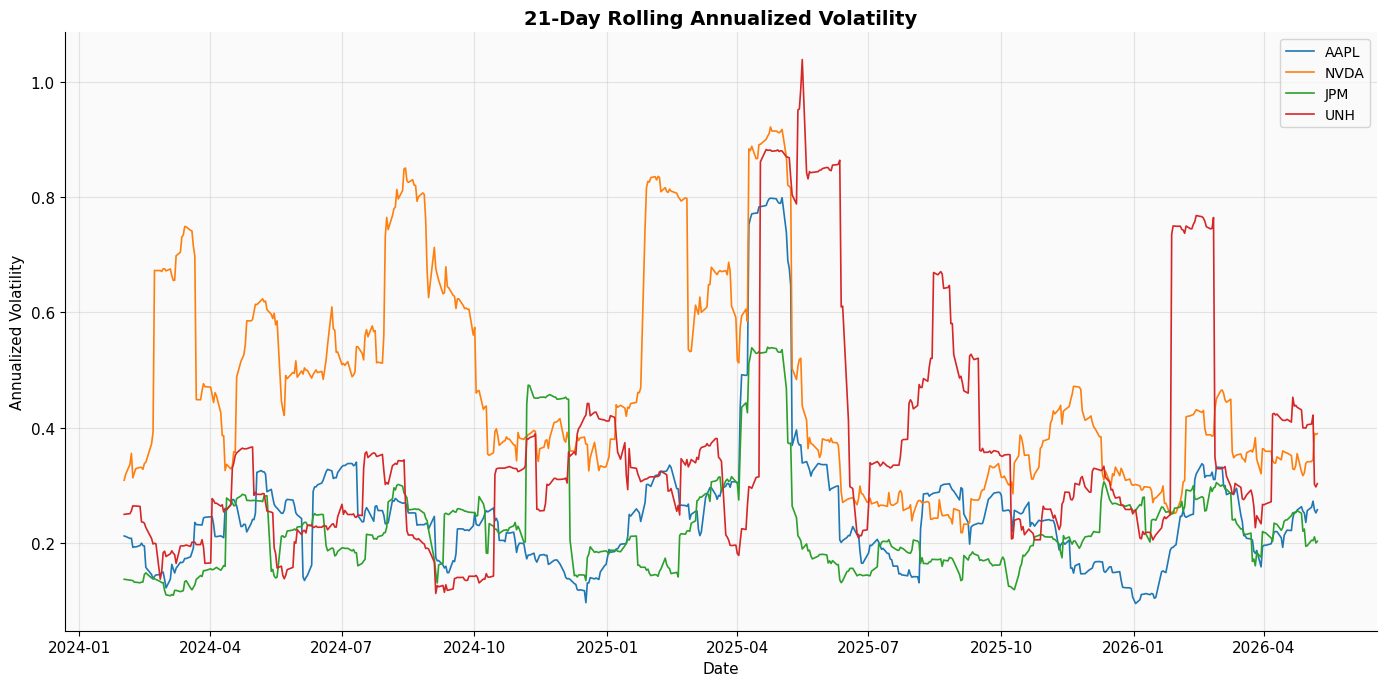

In [8]:
rolling_vol = returns.rolling(window=21).std() * np.sqrt(252)

highlight = ["AAPL", "NVDA", "JPM", "UNH"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(14, 7))
for ticker, color in zip(highlight, colors):
    ax.plot(rolling_vol[ticker], label=ticker, linewidth=1.2, color=color)

ax.set_title("21-Day Rolling Annualized Volatility", fontsize=14, fontweight="bold")
ax.set_ylabel("Annualized Volatility")
ax.set_xlabel("Date")
ax.legend(fontsize=10)
plt.tight_layout()

**Volatility clustering:** large moves tend to follow large moves, and small moves follow small moves. First documented by Mandelbrot (1963).

**Mechanism:** When a shock occurs (earnings surprise, central bank decision, geopolitical event), it creates uncertainty. Traders reprice risk, hedging activity increases, stop-losses trigger — this feeds on itself until the market digests the new information and settles.

**Rolling-window artefact:** The 21-day window acts as a memory buffer. A single large daily return enters the window and stays in the calculation for 21 days; when it exits, volatility can drop abruptly. This explains the sharp edges and plateau-like structure in the plots. The multi-window comparison below helps distinguish this artefact from genuine clustering.

**Implications for quantitative trading:**
- Position sizing should adapt to the current volatility regime — smaller positions during high-vol periods.
- Volatility-targeting strategies need real-time volatility estimates, which motivates GARCH-family models (explored in later phases).
- The standard $\sqrt{252}$ annualization assumes constant volatility — clearly an approximation.

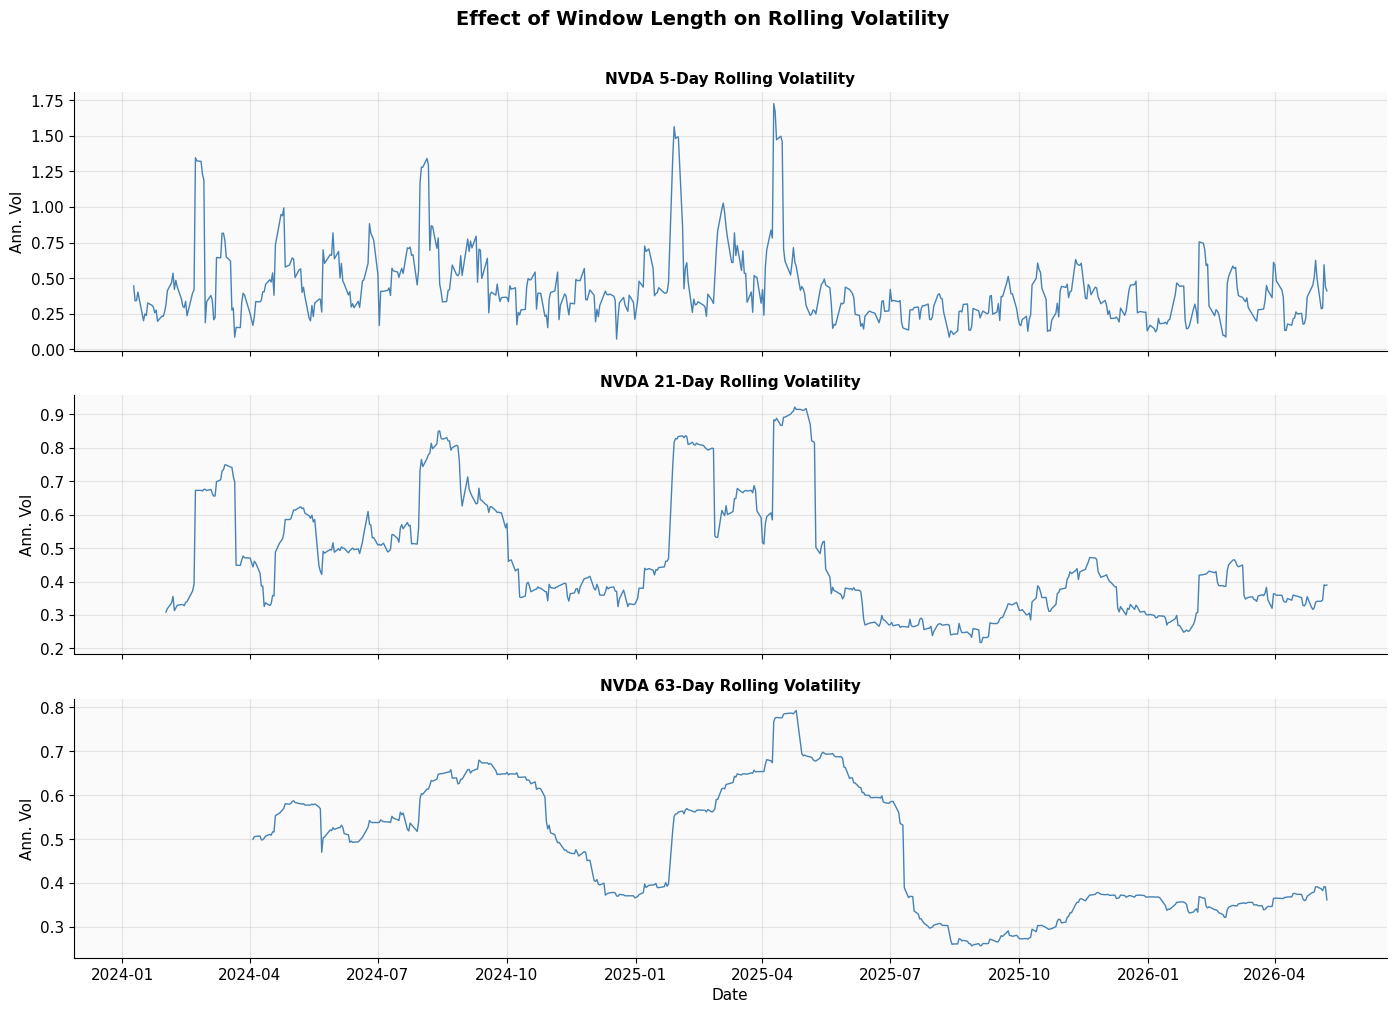

In [9]:
windows = [5, 21, 63]
fig, axes_arr = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes = np.asarray(axes_arr).flatten()

for ax, window in zip(axes, windows):
    vol = returns["NVDA"].rolling(window=window).std() * np.sqrt(252)
    ax.plot(vol, color="steelblue", linewidth=1.0)
    ax.set_ylabel("Ann. Vol")
    ax.set_title(
        f"NVDA {window}-Day Rolling Volatility",
        fontsize=11, fontweight="bold",
    )

axes[-1].set_xlabel("Date")
fig.suptitle(
    "Effect of Window Length on Rolling Volatility",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()

**Separating artefact from signal:** The multi-window comparison (5, 21, 63 days) above helps disentangle the rolling-window artefact from genuine volatility persistence. If clustering were purely an artefact of the window, shorter windows would show no persistence at all. Instead, even the 5-day window shows extended high-volatility episodes.

A more rigorous test is the **autocorrelation of squared returns** — if $r_t^2$ is positively autocorrelated, volatility is genuinely persistent regardless of any smoothing window. The plot below provides visual evidence; formal testing via GARCH models is deferred to later phases.

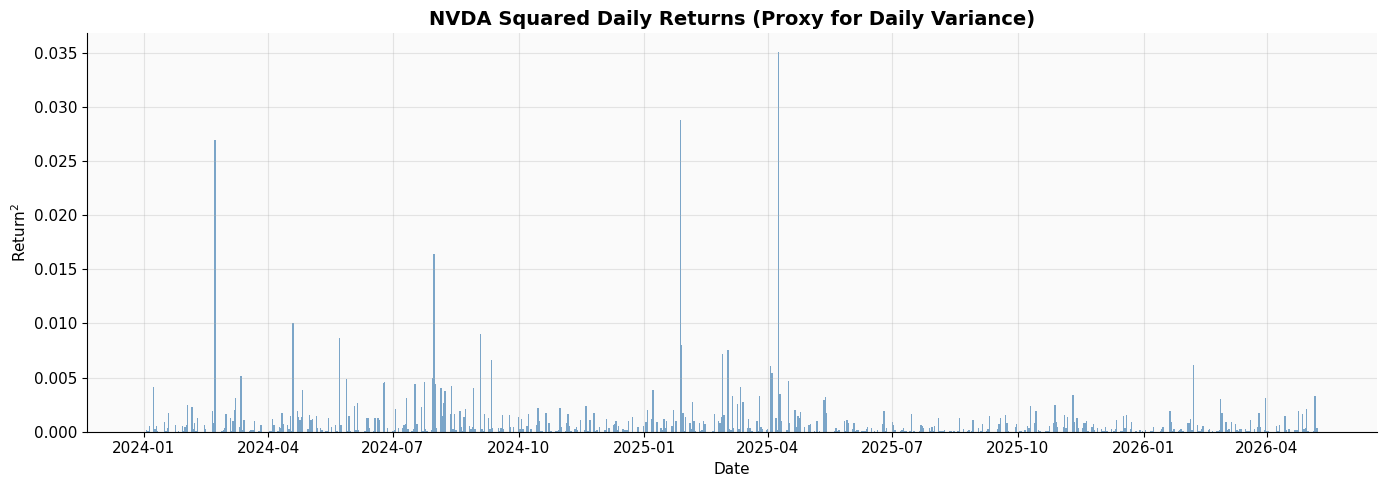

In [10]:
nvda_sq = returns["NVDA"] ** 2

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    nvda_sq.index, nvda_sq.to_numpy(),
    color="steelblue", width=1.0, alpha=0.7,
)
ax.set_title(
    "NVDA Squared Daily Returns (Proxy for Daily Variance)",
    fontsize=14, fontweight="bold",
)
ax.set_ylabel("Return$^2$")
ax.set_xlabel("Date")
plt.tight_layout()

## 7. Performance summary

Full metrics including benchmark-relative analytics (vs SPY) and distributional characteristics, computed via `qre.analytics.metrics.full_summary`. All ratios use 252 trading days per year. Sharpe, Sortino, and alpha assume zero risk-free rate.

In [11]:
# Load SPY as benchmark
spy_closes = store.load("SPY", "1d")["close"]
spy_ret = spy_closes.pct_change().dropna()

metrics_table = pd.DataFrame({
    ticker: full_summary(returns[ticker], spy_ret)
    for ticker in tickers
}).T.round(4)

# Also add SPY itself (standalone metrics only)
spy_standalone = summary(spy_ret)
metrics_table.loc["SPY"] = pd.Series(
    full_summary(spy_ret, spy_ret)
).round(4)

highlight_cols = [
    "sharpe_ratio", "annualized_return", "alpha", "beta",
]
metrics_table.style.format("{:.4f}").background_gradient(
    cmap="RdYlGn", subset=highlight_cols,
)

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,profit_factor,beta,alpha,tracking_error,information_ratio,up_capture,down_capture,skewness,excess_kurtosis,value_at_risk_95,cvar_95,tail_ratio,expected_tail_ratio,best_day,worst_day
NVDA,0.8978,0.4918,1.5490,1.5910,-0.3688,2.4343,0.5467,1.3108,2.0643,0.3182,0.4018,1.3611,2.3879,2.0490,0.1923,5.0864,-0.0439,-0.0668,1.0391,1.0600,0.1872,-0.1697
AAPL,0.2216,0.2749,0.8644,0.8912,-0.3336,0.6641,0.5399,1.1771,1.1483,-0.0091,0.2055,0.1106,1.0605,1.0472,0.8758,12.5624,-0.0259,-0.0381,0.9907,1.0826,0.1533,-0.0925
MSFT,0.0571,0.2404,0.3513,0.3383,-0.3391,0.1684,0.5263,1.0661,0.9653,-0.1230,0.1840,-0.7089,0.9632,1.1301,-0.1466,7.9667,-0.0243,-0.0355,0.8811,0.8984,0.1013,-0.0999
GOOGL,0.5827,0.3032,1.6660,1.7422,-0.2981,1.9551,0.5586,1.3397,1.1249,0.2634,0.2446,1.1869,1.3372,1.0403,0.4798,4.7704,-0.0257,-0.0402,1.1103,1.1573,0.1022,-0.0750
AMZN,0.2916,0.3134,0.9729,0.9937,-0.3088,0.9445,0.5348,1.1851,1.3845,0.0074,0.2297,0.3920,1.4529,1.4629,0.2406,5.0119,-0.0278,-0.0427,1.0513,1.0649,0.1198,-0.0898
META,0.2780,0.3790,0.8337,0.9028,-0.3415,0.8141,0.5246,1.1728,1.4549,0.0034,0.3075,0.3288,1.4265,1.4135,1.1959,13.6335,-0.0300,-0.0503,1.1044,1.1329,0.2032,-0.1133
JPM,0.3021,0.2426,1.2096,1.1517,-0.2442,1.2368,0.5620,1.2489,0.9216,0.0954,0.1928,0.4075,0.9706,0.8549,0.0718,8.7500,-0.0226,-0.0374,0.9030,0.8590,0.1154,-0.0749
GS,0.4885,0.2930,1.5042,1.5248,-0.3090,1.5812,0.5586,1.3141,1.3153,0.1581,0.2096,1.0774,1.4572,1.2833,0.4118,8.4618,-0.0241,-0.0410,1.0965,1.0289,0.1310,-0.0921
V,0.1010,0.2091,0.5647,0.5370,-0.2038,0.4958,0.5501,1.1104,0.6889,-0.0299,0.1844,-0.5248,0.5984,0.6126,0.0527,8.2801,-0.0181,-0.0317,0.9813,0.9131,0.0826,-0.0774
XOM,0.1976,0.2279,0.9057,0.8598,-0.1892,1.0446,0.5348,1.1626,0.2981,0.1424,0.2497,-0.0338,0.1565,-0.0790,-0.5417,1.8833,-0.0234,-0.0337,1.0030,0.8557,0.0500,-0.0720


**Observations:**

*Top performers:* NVDA (90% annualized return), GOOGL (58%), WMT (49%), GS (49%). WMT stands out as the most efficient risk-adjusted performer — highest Sharpe (1.89) with relatively low volatility (22%).

*Underperformer:* UNH — the only negative return in the basket, worst drawdown (-61%), and profit factor below 1.0.

*Patterns:*
- **Win rates cluster around 52–56%.** Even the best-performing stocks only rise slightly more than half of all trading days. Profitability is driven by the *magnitude* of wins vs. losses (profit factor), not frequency.
- **Risk-return tradeoff.** Lower-volatility names (JNJ, PG, V) exhibit smaller drawdowns but also lower returns — the classic cross-sectional relationship.
- **Drawdowns are substantial across the board.** Every name experienced a peak-to-trough decline of at least 14%, and most exceeded 25%. This underscores the importance of position sizing and risk management even in a strong market environment.
- **Beta decomposition.** Most tech names have beta > 1.5, meaning their returns are amplified market moves. Alpha separates genuine stock-specific outperformance from beta exposure — NVDA and GOOGL show strong positive alpha even after adjusting for their high beta.

## 8. Skewness vs. Kurtosis: individual stocks vs. the index

How do distributional properties change when you compare the small basket of stocks with the larger market, represented by the S&P 500?

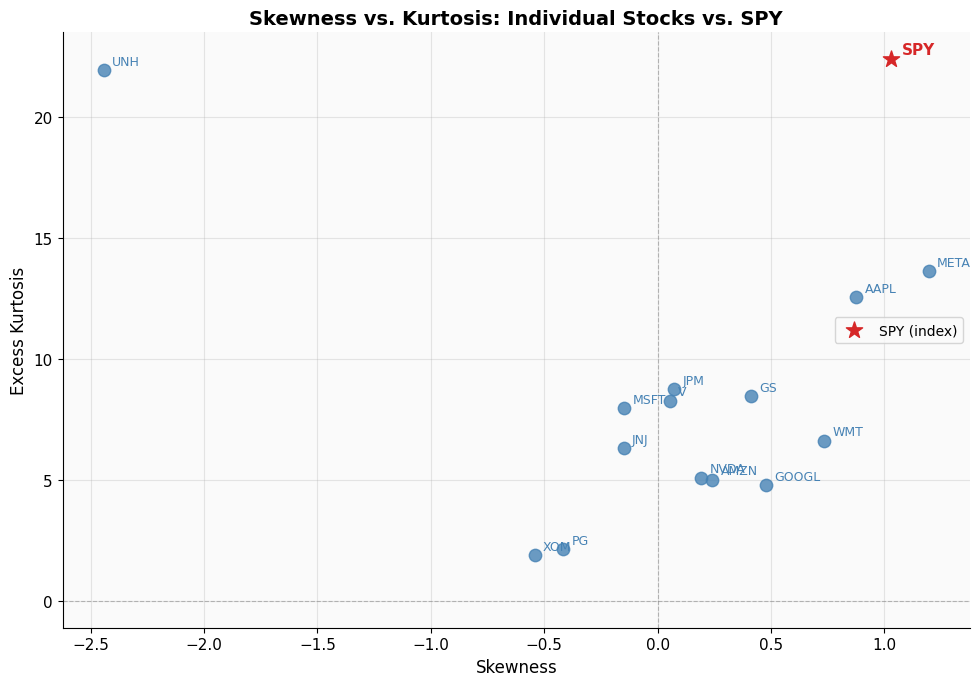

In [12]:
skew_kurt = metrics_table[["skewness", "excess_kurtosis"]]

fig, ax = plt.subplots(figsize=(10, 7))

# Individual stocks
stocks = skew_kurt.drop("SPY", errors="ignore")
ax.scatter(
    stocks["skewness"], stocks["excess_kurtosis"],
    s=80, color="steelblue", alpha=0.8, zorder=3,
)
for ticker in stocks.index:
    ax.annotate(
        ticker,
        (stocks.loc[ticker, "skewness"],
         stocks.loc[ticker, "excess_kurtosis"]),
        textcoords="offset points", xytext=(6, 4),
        fontsize=9, color="steelblue",
    )

# SPY highlighted
spy_row = skew_kurt.loc["SPY"]
ax.scatter(
    spy_row["skewness"], spy_row["excess_kurtosis"],
    s=150, color="#d62728", marker="*", zorder=4,
    label="SPY (index)",
)
ax.annotate(
    "SPY", (spy_row["skewness"], spy_row["excess_kurtosis"]),
    textcoords="offset points", xytext=(8, 4),
    fontsize=11, fontweight="bold", color="#d62728",
)

# Reference lines
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel("Skewness", fontsize=12)
ax.set_ylabel("Excess Kurtosis", fontsize=12)
ax.set_title(
    "Skewness vs. Kurtosis: Individual Stocks vs. SPY",
    fontsize=14, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()